In [55]:
import scanpy as sc
import numpy as np 
import sys
import os
import pickle as pkl
from pathlib import Path
import pandas as pd
import yaml
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import math

sys.path.insert(0, "../../../../shared_utils/")
from experiment_utils import compute_sequential_local_penalization

In [56]:
# Annotation file 
ANNOTATION_CFG_FILE = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/annotation/default.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]

In [57]:
path_to_annotated_filter = Path("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/manually_filtered/original_bloodplus/annotated")

In [58]:
cell_type_dfs = {}

with open("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/manually_filtered/original_bloodplus/fitlered_populations.pkl", "rb") as file:
    cell_type_dfs = pkl.load(file)

## Plotting functions 

In [59]:
def plot_cell_type_vs_params(ct_df, cell_type, protocol_cols, idx_selected, ncols=3):
    # Copy and annotate 
    ct_df_copy = ct_df.copy()
    ct_df_copy["idx_selected"] = idx_selected

    # Set up plottig
    cell_type_safe = cell_type.replace(":", "/")
    n_params = len(protocol_cols)
    nrows = math.ceil(n_params / ncols)
    
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(3*ncols, 2*nrows))
    fig.subplots_adjust(hspace=0.9, wspace=0.6)
    axes = axes.flatten()

    for i, param in enumerate(protocol_cols):
        sns.scatterplot(
            data=ct_df_copy,
            x=param,
            y=f"{cell_type_safe}_prop",
            hue="idx_selected",
            ax=axes[i],
            s=20,
            alpha=0.6,
            edgecolor=None,
        )
        axes[i].set_title(f"{cell_type} vs {param}")

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

def plot_wucb_ranking_results(
    result_df,
    axes=None,
    column_to_track="losses",
    markersize=3
):
    tracked_acqs = result_df["acq_values"]
    tracked_losses = result_df[column_to_track]

    epochs = np.arange(1, len(tracked_acqs) + 1)

    if axes is None:
        fig, axes = plt.subplots(1, 2, figsize=(7, 4))
    ax1, ax2 = axes

    # Plot 1: Acquisition values
    ax1.plot(
        epochs,
        tracked_acqs,
        marker='o',
        linestyle='-',
        linewidth=1,
        markersize=markersize,
        markeredgewidth=0.5,
        color="firebrick"
    )
    ax1.set_title("Acquisition Value", fontsize=10)
    ax1.set_xlabel("Selection Step", fontsize=8)
    ax1.set_ylabel("Penalized Acquisition Value", fontsize=8)
    ax1.grid(True, linestyle='--', alpha=0.7)

    # Plot 2: Predicted losses
    ax2.plot(
        epochs,
        tracked_losses,
        marker='s',
        linestyle='-',
        linewidth=1,
        markersize=markersize,
        markeredgewidth=0.5,
        color="royalblue"
    )
    ax2.set_title("Predicted Loss", fontsize=10)
    ax2.set_xlabel("Selection Step", fontsize=8)
    ax2.set_ylabel("Mean Predicted Loss", fontsize=8)
    ax2.grid(True, linestyle='--', alpha=0.7)

    return axes

## Pareto optimization 

In [60]:
def is_pareto_efficient(gains: np.ndarray) -> np.ndarray:
    costs = -gains  # convert to minimisation
    n = costs.shape[0]
    is_efficient = np.ones(n, dtype=bool)
    for i in range(n):
        if not is_efficient[i]:
            continue
        # i is dominated if some other efficient point is <= in all dims and < in at least one
        dominated = (
            np.all(costs <= costs[i], axis=1) &
            np.any(costs < costs[i], axis=1)
        )
        dominated[i] = False          # a point cannot dominate itself
        is_efficient[i] = not dominated.any()
        # points dominated by i can be removed early
        is_efficient &= ~dominated
    return is_efficient
 
 
def pareto_front_indices(
    gains: np.ndarray,
    uncertainties: np.ndarray,
) -> np.ndarray:
    
    objectives = np.column_stack([gains, uncertainties])
    mask = is_pareto_efficient(objectives)
    return np.where(mask)[0]

 
def farthest_point_sampling(
    condition_matrix: np.ndarray,
    candidate_indices: np.ndarray,
    budget: int,
    seed_index: int | None = None,
) -> np.ndarray:
    if budget >= len(candidate_indices):
        return candidate_indices.copy()
 
    pool = condition_matrix[candidate_indices]          # (M, D)
    M = len(candidate_indices)
 
    seed = 0 if seed_index is None else seed_index
    selected_local = [seed]
    min_dist = np.full(M, np.inf)
 
    for _ in range(budget - 1):
        last = pool[selected_local[-1]]
        # Euclidean distance from last selected point to every pool point
        diffs = pool - last                             # (M, D)
        dist_to_last = np.einsum("ij,ij->i", diffs, diffs)  # squared L2
        min_dist = np.minimum(min_dist, dist_to_last)
        # pick the point farthest from all already-selected points
        next_local = int(np.argmax(min_dist))
        selected_local.append(next_local)
 
    return candidate_indices[np.array(selected_local)]

 
def select_candidates(
    proportions: np.ndarray,
    uncertainties: np.ndarray,
    condition_matrix: np.ndarray,
    budget: int,
    alpha: float = 0.5,
    use_diversity: bool = True,
) -> dict:

    gain = -np.asarray(proportions, dtype=float)  # Higher better
    uncertainties = np.asarray(uncertainties, dtype=float) # Higher better
    condition_matrix = np.asarray(condition_matrix, dtype=float)  # Features 
    N = len(gain)
 
    # --- normalise to [0,1] for comparability ---
    def _norm(x):
        lo, hi = x.min(), x.max()
        return (x - lo) / (hi - lo + 1e-12)

    # Normalize values
    p_norm = _norm(gain)
    u_norm = _norm(uncertainties)
    scores = alpha * p_norm + (1 - alpha) * u_norm
 
    # --- Pareto front ---
    pareto_idx = pareto_front_indices(p_norm, u_norm)
    on_pareto = np.zeros(N, dtype=bool)
    on_pareto[pareto_idx] = True
 
    # --- selection ---
    if len(pareto_idx) >= budget:
        print("More pareto points than budget")
        # We have enough Pareto-optimal candidates — apply diversity or score ranking
        if use_diversity:
            selected = farthest_point_sampling(condition_matrix, pareto_idx, budget)
        else:
            order = np.argsort(-scores[pareto_idx])
            selected = pareto_idx[order[:budget]]
    else:
        print("Less pareto points than budget")
        # Pareto front smaller than budget — fill remainder by scalarised score
        selected = pareto_idx.copy()
        remaining_needed = budget - len(selected)
        non_pareto = np.where(~on_pareto)[0]
        order = np.argsort(-scores[non_pareto])
        selected = np.concatenate([selected, non_pareto[order[:remaining_needed]]])
 
    return {
        "selected_indices": selected,
        "pareto_indices": pareto_idx,
        "scores": scores,
        "on_pareto": on_pareto,
    }

## Apply to solutions 

EryPro
Number of observations: 3138
Less pareto points than budget
1


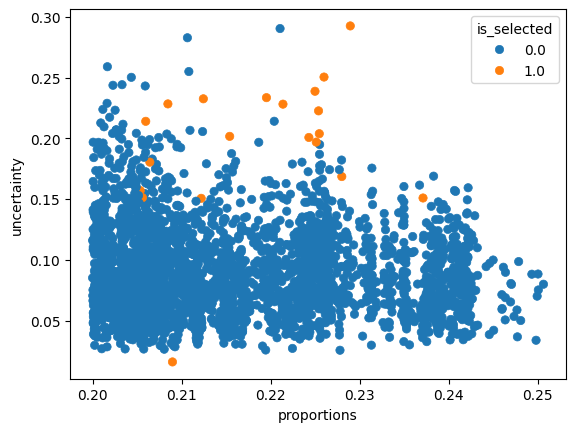

HSCs
Number of observations: 236
Less pareto points than budget
1


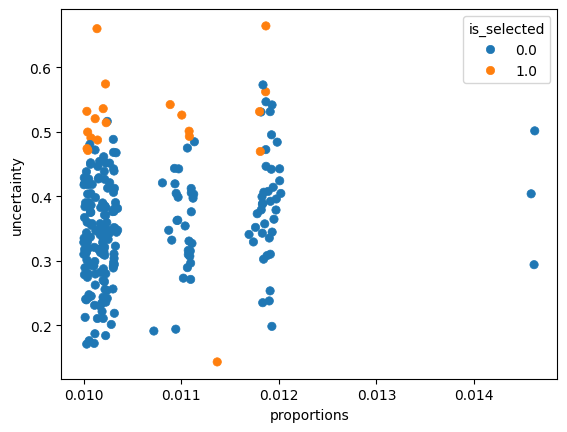

late_MgkPro
Number of observations: 1409
More pareto points than budget
1059


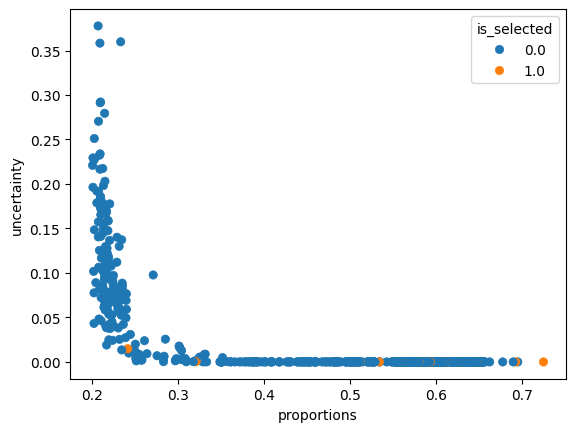

preProB
Number of observations: 3075
Less pareto points than budget
0


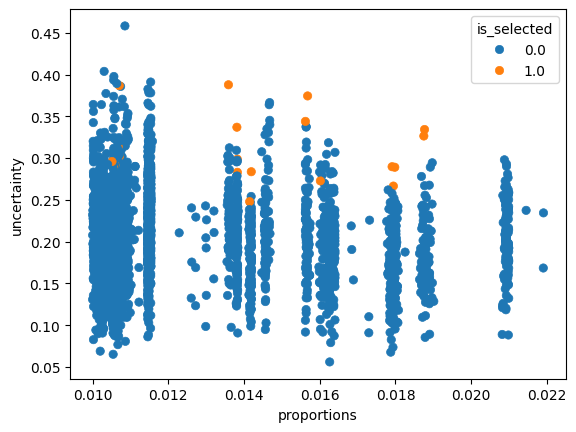

In [69]:
for cell_type in cell_type_dfs:
    if cell_type=="ProB":
        continue
        
    print(cell_type)
    print("Number of observations:", cell_type_dfs[cell_type].shape[0])
    loss = cell_type_dfs[cell_type]["target_ct_loss_mean"]
    uncertainty = cell_type_dfs[cell_type]["uncertainty_loss"]
    condition_matrix = cell_type_dfs[cell_type].loc[:, protocol_cols]

    # Pareto selection
    candidates_score  = select_candidates(
        proportions=loss,
        uncertainties=uncertainty,
        condition_matrix=condition_matrix,
        budget=20,
        alpha=0.5, 
        use_diversity=True)

    idx_selected = np.zeros(cell_type_dfs[cell_type].shape[0])
    idx_selected[candidates_score["selected_indices"]] = 1.0

    df_to_plot_diversity  = {"uncertainty": cell_type_dfs[cell_type]["uncertainty_loss"], 
                             "proportions": cell_type_dfs[cell_type][f"{cell_type}_prop"], 
                             "is_selected": idx_selected}
    print(len(candidates_score["pareto_indices"]))
    
    sns.scatterplot(df_to_plot_diversity, x="proportions", y="uncertainty", hue="is_selected", edgecolor=None)
    plt.show()